In [1]:
import sys
print(sys.executable)

C:\Anaconda\envs\core_data\python.exe


In [2]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("sealice_project/data/ms_sea_lice_archive.csv")
df.head()

C:\Users\shenr\AppData\Local\Temp\ipykernel_16608\1931500708.py:1: DtypeWarning: Columns (0: SG Action) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sealice_project/data/ms_sea_lice_archive.csv")


,Site No,Site Name,Business No,Business Name,Year,Week No,Week Beginning,Weekly Average AF,Reason For No Count,SG Action,Mitigation,Additional Mitigation,Additional Information,National Grid Reference,Easting,Northing
0,FS0001,Evanachan,FB0012,Otter Ferry Seafish Ltd,2025,52,2025-12-22,0.0,NaN,NaN,NaN,NaN,NaN,NR945867,194500.0,686700.0
1,FS0001,Evanachan,FB0012,Otter Ferry Seafish Ltd,2025,51,2025-12-15,0.0,NaN,NaN,NaN,NaN,NaN,NR945867,194500.0,686700.0
2,FS0001,Evanachan,FB0012,Otter Ferry Seafish Ltd,2025,50,2025-12-08,0.0,NaN,NaN,NaN,NaN,NaN,NR945867,194500.0,686700.0
3,FS0001,Evanachan,FB0012,Otter Ferry Seafish Ltd,2025,49,2025-12-01,0.0,NaN,NaN,NaN,NaN,NaN,NR945867,194500.0,686700.0
4,FS0001,Evanachan,FB0012,Otter Ferry Seafish Ltd,2025,48,2025-11-24,0.0,NaN,NaN,NaN,NaN,NaN,NR945867,194500.0,686700.0


In [9]:
df = df[[
    "Year",
    "Week Beginning",
    "Weekly Average AF",
    "Site No",
    "Site Name",
    "Easting",
    "Northing"
]]
df

,Year,Week Beginning,Weekly Average AF,Site No,Site Name,Easting,Northing
0,2025,2025-12-22,0.00,FS0001,Evanachan,194500.0,686700.0
1,2025,2025-12-15,0.00,FS0001,Evanachan,194500.0,686700.0
2,2025,2025-12-08,0.00,FS0001,Evanachan,194500.0,686700.0
3,2025,2025-12-01,0.00,FS0001,Evanachan,194500.0,686700.0
4,2025,2025-11-24,0.00,FS0001,Evanachan,194500.0,686700.0
...,...,...,...,...,...,...,...
34502,2024,2024-07-08,0.01,FS1365,North Kilbrannan,183700.0,649700.0
34503,2024,2024-07-01,0.00,FS1365,North Kilbrannan,183700.0,649700.0
34504,2021,2021-10-18,0.10,Fs0860,Shapinsay,350100.0,1021300.0
34505,2021,2021-10-18,0.00,Fs1018,Slocka Ronas Voe,428500.0,1182700.0


In [10]:
df = df.rename(columns={
    "Week Beginning": "week_start",
    "Weekly Average AF": "lice_avg",
    "Site No": "site_id",
    "Site Name": "site_name",
    "Easting": "easting",
    "Northing": "northing"
})
df

,Year,week_start,lice_avg,site_id,site_name,easting,northing
0,2025,2025-12-22,0.00,FS0001,Evanachan,194500.0,686700.0
1,2025,2025-12-15,0.00,FS0001,Evanachan,194500.0,686700.0
2,2025,2025-12-08,0.00,FS0001,Evanachan,194500.0,686700.0
3,2025,2025-12-01,0.00,FS0001,Evanachan,194500.0,686700.0
4,2025,2025-11-24,0.00,FS0001,Evanachan,194500.0,686700.0
...,...,...,...,...,...,...,...
34502,2024,2024-07-08,0.01,FS1365,North Kilbrannan,183700.0,649700.0
34503,2024,2024-07-01,0.00,FS1365,North Kilbrannan,183700.0,649700.0
34504,2021,2021-10-18,0.10,Fs0860,Shapinsay,350100.0,1021300.0
34505,2021,2021-10-18,0.00,Fs1018,Slocka Ronas Voe,428500.0,1182700.0


In [11]:
df["week_start"] = pd.to_datetime(df["week_start"])

In [12]:
df["lice_avg"] = pd.to_numeric(df["lice_avg"], errors="coerce")
df["easting"] = pd.to_numeric(df["easting"], errors="coerce")
df["northing"] = pd.to_numeric(df["northing"], errors="coerce")

In [13]:
df = df.dropna(subset=["lice_avg", "easting", "northing", "week_start"])

In [14]:
df

,Year,week_start,lice_avg,site_id,site_name,easting,northing
0,2025,2025-12-22,0.00,FS0001,Evanachan,194500.0,686700.0
1,2025,2025-12-15,0.00,FS0001,Evanachan,194500.0,686700.0
2,2025,2025-12-08,0.00,FS0001,Evanachan,194500.0,686700.0
3,2025,2025-12-01,0.00,FS0001,Evanachan,194500.0,686700.0
4,2025,2025-11-24,0.00,FS0001,Evanachan,194500.0,686700.0
...,...,...,...,...,...,...,...
34502,2024,2024-07-08,0.01,FS1365,North Kilbrannan,183700.0,649700.0
34503,2024,2024-07-01,0.00,FS1365,North Kilbrannan,183700.0,649700.0
34504,2021,2021-10-18,0.10,Fs0860,Shapinsay,350100.0,1021300.0
34505,2021,2021-10-18,0.00,Fs1018,Slocka Ronas Voe,428500.0,1182700.0


In [15]:
df = df.sort_values(by=["site_id", "week_start"])

In [16]:
df

,Year,week_start,lice_avg,site_id,site_name,easting,northing
58,2024,2024-10-21,0.00,FS0001,Evanachan Salt Water,194500.0,686700.0
57,2024,2024-10-28,0.00,FS0001,Evanachan Salt Water,194500.0,686700.0
56,2024,2024-11-04,0.00,FS0001,Evanachan Salt Water,194500.0,686700.0
55,2024,2024-11-11,0.00,FS0001,Evanachan Salt Water,194500.0,686700.0
54,2024,2024-11-18,0.00,FS0001,Evanachan Salt Water,194500.0,686700.0
...,...,...,...,...,...,...,...
34473,2025,2025-01-27,1.24,FS1365,North Kilbrannan,183700.0,649700.0
34472,2025,2025-02-03,1.28,FS1365,North Kilbrannan,183700.0,649700.0
34504,2021,2021-10-18,0.10,Fs0860,Shapinsay,350100.0,1021300.0
34505,2021,2021-10-18,0.00,Fs1018,Slocka Ronas Voe,428500.0,1182700.0


In [19]:
df = df.sort_values(by="week_start", ascending=False)
df = df.reset_index(drop=True)
df

,Year,week_start,lice_avg,site_id,site_name,easting,northing
0,2025,2025-12-22,0.04,FS1335,"Swarta Skerry, Dury Voe",447300.0,1162300.0
1,2025,2025-12-22,0.03,FS0645,Kirk Noust,344900.0,1029100.0
2,2025,2025-12-22,0.50,FS0519,Maol Ban,156300.0,831100.0
3,2025,2025-12-22,0.03,FS0549,Tanera,199500.0,907500.0
4,2025,2025-12-22,0.00,FS0559,Ardyne,209300.0,668900.0
...,...,...,...,...,...,...,...
28249,2021,2021-03-29,2.15,FS1176,Eilean Grianain,181600.0,641200.0
28250,2021,2021-03-29,0.00,FS1198,South Cava,333300.0,998900.0
28251,2021,2021-03-29,0.05,FS1209,Ouseness,346500.0,1049700.0
28252,2021,2021-03-29,0.02,FS1210,Vestness,348000.0,1049300.0


In [20]:
df.info()
df.isna().sum()
df.describe()
df

<class 'pandas.DataFrame'>
RangeIndex: 28254 entries, 0 to 28253
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year        28254 non-null  int64         
 1   week_start  28254 non-null  datetime64[us]
 2   lice_avg    28254 non-null  float64       
 3   site_id     28254 non-null  str           
 4   site_name   28254 non-null  str           
 5   easting     28254 non-null  float64       
 6   northing    28254 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 1.5 MB


,Year,week_start,lice_avg,site_id,site_name,easting,northing
0,2025,2025-12-22,0.04,FS1335,"Swarta Skerry, Dury Voe",447300.0,1162300.0
1,2025,2025-12-22,0.03,FS0645,Kirk Noust,344900.0,1029100.0
2,2025,2025-12-22,0.50,FS0519,Maol Ban,156300.0,831100.0
3,2025,2025-12-22,0.03,FS0549,Tanera,199500.0,907500.0
4,2025,2025-12-22,0.00,FS0559,Ardyne,209300.0,668900.0
...,...,...,...,...,...,...,...
28249,2021,2021-03-29,2.15,FS1176,Eilean Grianain,181600.0,641200.0
28250,2021,2021-03-29,0.00,FS1198,South Cava,333300.0,998900.0
28251,2021,2021-03-29,0.05,FS1209,Ouseness,346500.0,1049700.0
28252,2021,2021-03-29,0.02,FS1210,Vestness,348000.0,1049300.0


In [21]:
df.to_csv("sealice_project/data/lice_clean.csv", index=False)

In [22]:
test = pd.read_csv("sealice_project/data/lice_clean.csv")
test.head()

,Year,week_start,lice_avg,site_id,site_name,easting,northing
0,2025,2025-12-22,0.04,FS1335,"Swarta Skerry, Dury Voe",447300.0,1162300.0
1,2025,2025-12-22,0.03,FS0645,Kirk Noust,344900.0,1029100.0
2,2025,2025-12-22,0.50,FS0519,Maol Ban,156300.0,831100.0
3,2025,2025-12-22,0.03,FS0549,Tanera,199500.0,907500.0
4,2025,2025-12-22,0.00,FS0559,Ardyne,209300.0,668900.0


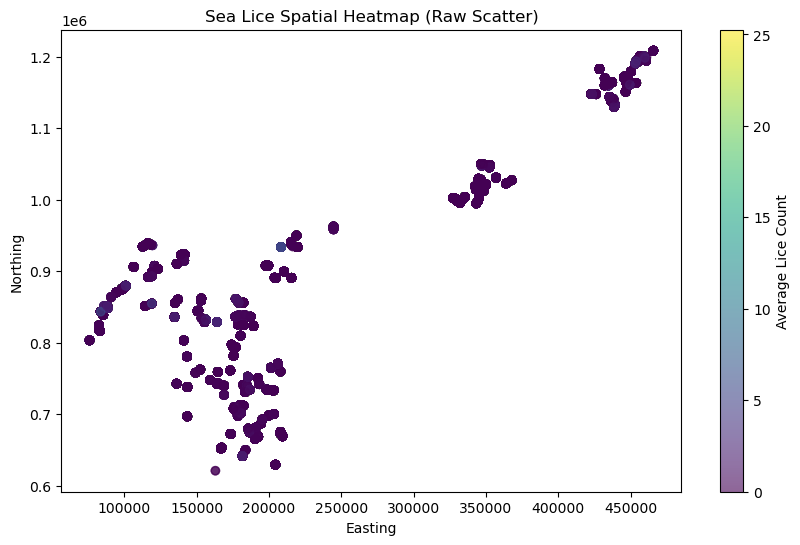

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(
    df["easting"],
    df["northing"],
    c=df["lice_avg"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Average Lice Count")
plt.title("Sea Lice Spatial Heatmap (Raw Scatter)")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

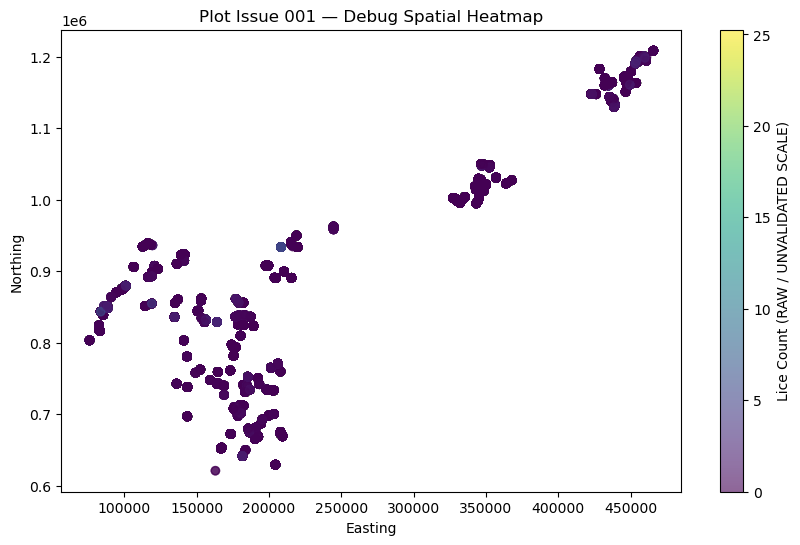

In [24]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["easting"],
    df["northing"],
    c=df["lice_avg"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Lice Count (RAW / UNVALIDATED SCALE)")
plt.title("Plot Issue 001 — Debug Spatial Heatmap")
plt.xlabel("Easting")
plt.ylabel("Northing")

plt.savefig("sealice_project/diagnostics/plot_issue_001.pdf")
plt.show()

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28254 entries, 0 to 28253
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Year        28254 non-null  int64         
 1   week_start  28254 non-null  datetime64[us]
 2   lice_avg    28254 non-null  float64       
 3   site_id     28254 non-null  str           
 4   site_name   28254 non-null  str           
 5   easting     28254 non-null  float64       
 6   northing    28254 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(2)
memory usage: 1.5 MB


In [26]:
df[["lice_avg", "easting", "northing"]].describe()

,lice_avg,easting,northing
count,28254.000000,28254.000000,2.825400e+04
mean,0.522675,245222.616267,9.033776e+05
std,0.939661,121618.467743,1.701808e+05
min,0.000000,75900.000000,6.207000e+05
25%,0.010000,159200.000000,7.577000e+05
50%,0.180000,191800.000000,8.739000e+05
75%,0.600000,347000.000000,1.027100e+06
max,25.260000,465700.000000,1.208200e+06


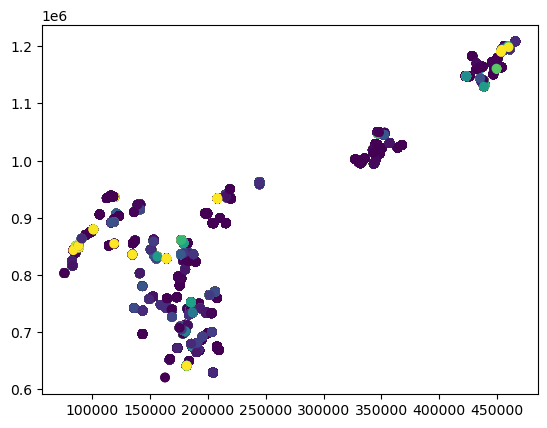

In [27]:
plt.scatter(
    df["easting"],
    df["northing"],
    c=df["lice_avg"],
    cmap="viridis",
    vmin=0,
    vmax=2
)

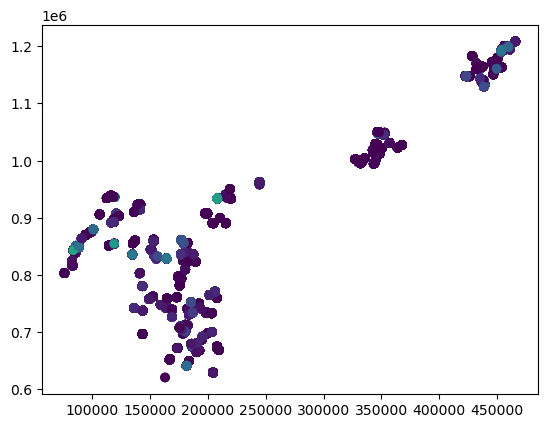

In [28]:
import numpy as np

df["lice_log"] = np.log1p(df["lice_avg"])
plt.scatter(df["easting"], df["northing"], c=df["lice_log"])

In [29]:
normal = df[df["lice_avg"] <= 2]
outliers = df[df["lice_avg"] > 2]

In [30]:
normal

,Year,week_start,lice_avg,site_id,site_name,easting,northing,lice_log
0,2025,2025-12-22,0.04,FS1335,"Swarta Skerry, Dury Voe",447300.0,1162300.0,0.039221
1,2025,2025-12-22,0.03,FS0645,Kirk Noust,344900.0,1029100.0,0.029559
2,2025,2025-12-22,0.50,FS0519,Maol Ban,156300.0,831100.0,0.405465
3,2025,2025-12-22,0.03,FS0549,Tanera,199500.0,907500.0,0.029559
4,2025,2025-12-22,0.00,FS0559,Ardyne,209300.0,668900.0,0.000000
...,...,...,...,...,...,...,...,...
28247,2021,2021-03-29,1.48,FS1121,"Bight of Bellister, Dury Voe",449400.0,1160800.0,0.908259
28250,2021,2021-03-29,0.00,FS1198,South Cava,333300.0,998900.0,0.000000
28251,2021,2021-03-29,0.05,FS1209,Ouseness,346500.0,1049700.0,0.048790
28252,2021,2021-03-29,0.02,FS1210,Vestness,348000.0,1049300.0,0.019803


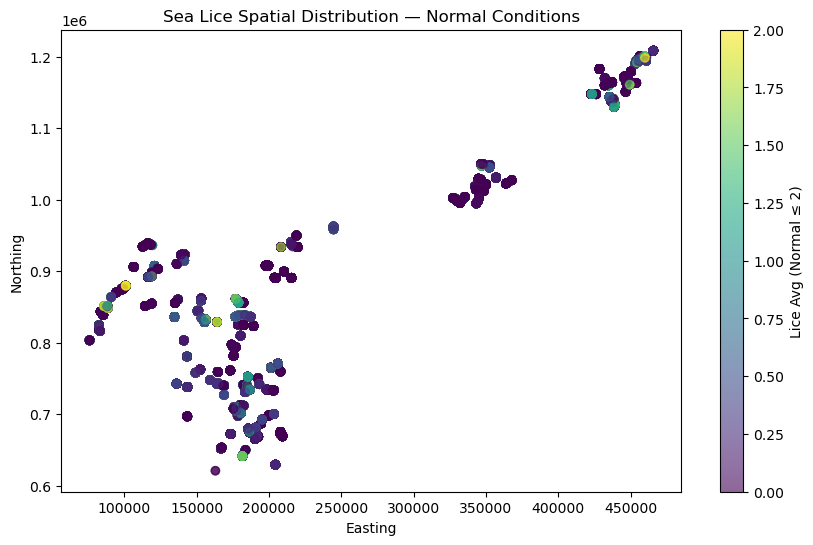

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    normal["easting"],
    normal["northing"],
    c=normal["lice_avg"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="Lice Avg (Normal ≤ 2)")
plt.title("Sea Lice Spatial Distribution — Normal Conditions")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

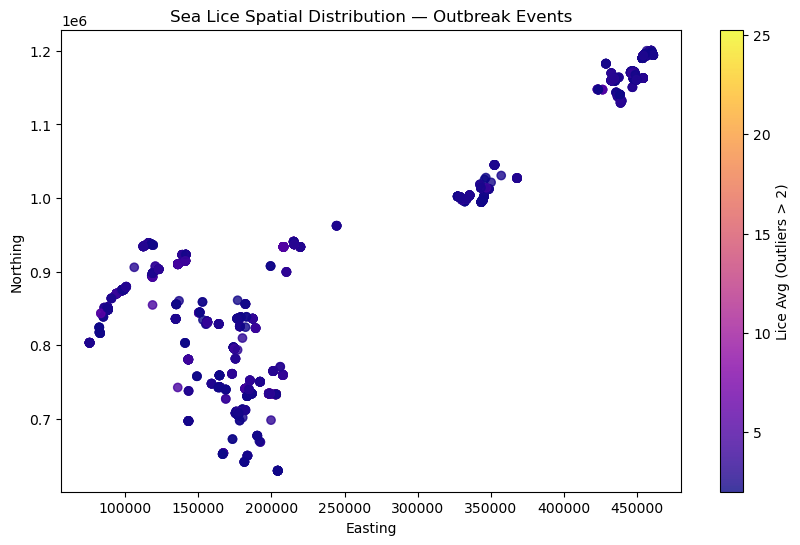

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(
    outliers["easting"],
    outliers["northing"],
    c=outliers["lice_avg"],
    cmap="plasma",
    alpha=0.8
)

plt.colorbar(label="Lice Avg (Outliers > 2)")
plt.title("Sea Lice Spatial Distribution — Outbreak Events")
plt.xlabel("Easting")
plt.ylabel("Northing")
plt.show()

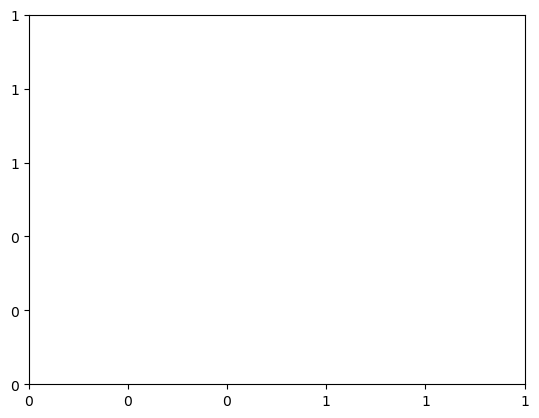

In [33]:
from matplotlib.ticker import StrMethodFormatter

ax = plt.gca()

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

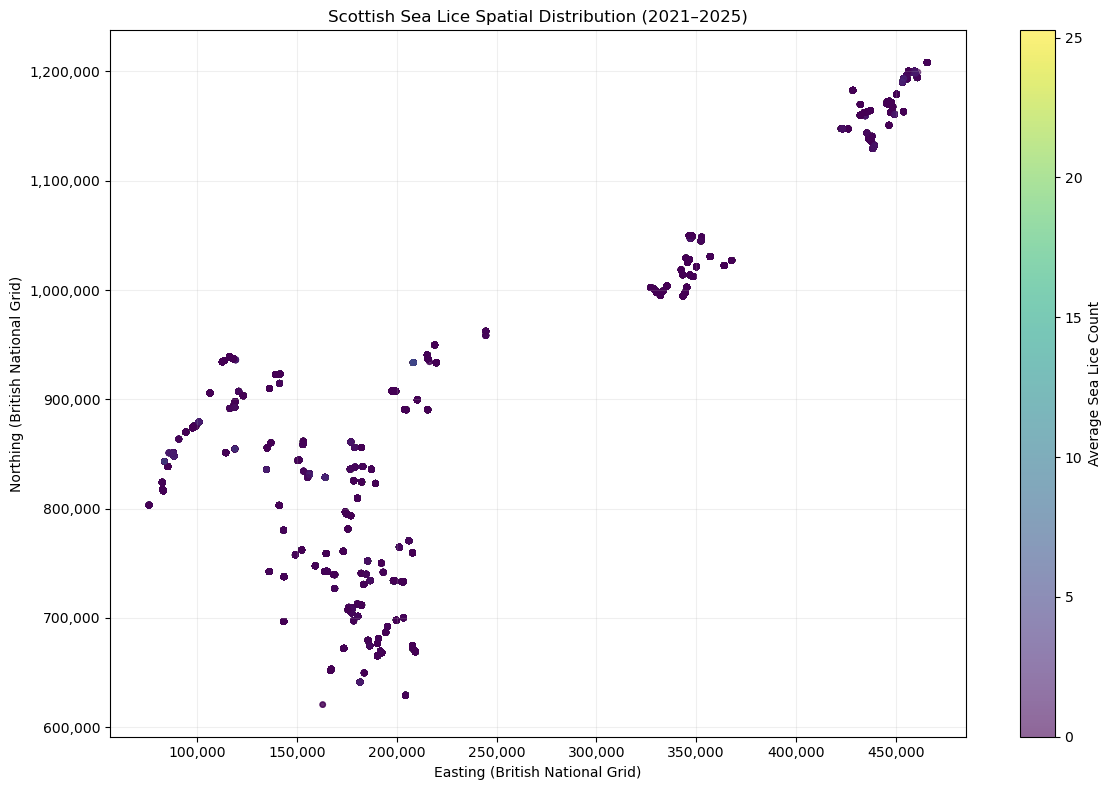

In [35]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df["easting"],
    df["northing"],
    c=df["lice_avg"],
    cmap="viridis",
    alpha=0.6,
    s=15
)

plt.colorbar(scatter, label="Average Sea Lice Count")

ax = plt.gca()

# Make coordinates easier to read
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.xlabel("Easting (British National Grid)")
plt.ylabel("Northing (British National Grid)")
plt.title("Scottish Sea Lice Spatial Distribution (2021–2025)")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

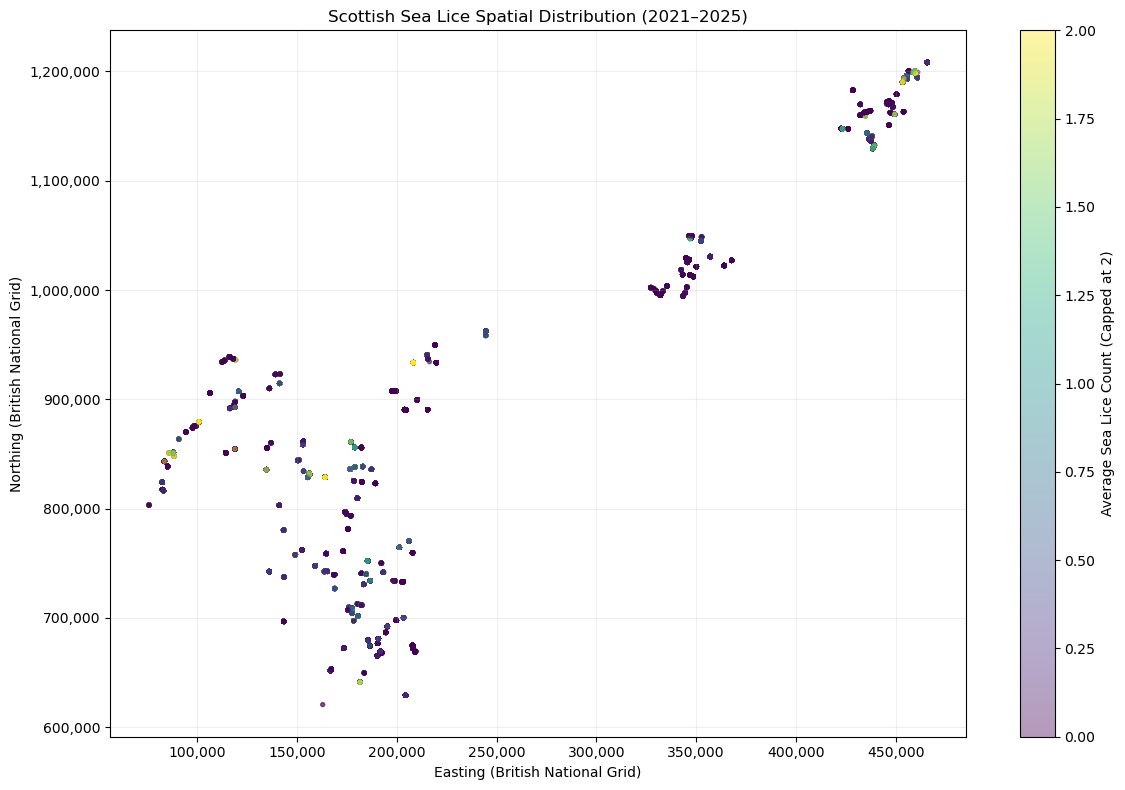

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

# Create figure
plt.figure(figsize=(12, 8))

# Scatter heatmap
scatter = plt.scatter(
    df["easting"],
    df["northing"],
    c=df["lice_avg"],
    cmap="viridis",
    alpha=0.4,      # Helps reveal dense clusters
    s=8,            # Smaller points reduce overlap
    vmin=0,
    vmax=2          # Focus on biologically relevant range
)

# Colour bar
plt.colorbar(
    scatter,
    label="Average Sea Lice Count (Capped at 2)"
)

# Format coordinate axes
ax = plt.gca()
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

# Labels and title
plt.xlabel("Easting (British National Grid)")
plt.ylabel("Northing (British National Grid)")
plt.title("Scottish Sea Lice Spatial Distribution (2021–2025)")

# Light grid
plt.grid(alpha=0.2)

# Prevent label clipping
plt.tight_layout()
plt.show()

In [38]:
df["lice_avg"].describe(percentiles=[0.90, 0.95, 0.99])

count    28254.000000
mean         0.522675
std          0.939661
min          0.000000
90%          1.570000
95%          2.180000
99%          4.060000
max         25.260000
Name: lice_avg, dtype: float64

In [39]:
df[df["lice_avg"] > 4]["lice_avg"].describe()

count    300.000000
mean       5.908930
std        2.867896
min        4.010000
25%        4.380000
50%        4.910000
75%        5.907500
max       25.260000
Name: lice_avg, dtype: float64

In [40]:
df.nlargest(
    20,
    "lice_avg"
)[["Year", "week_start", "site_name", "lice_avg"]]

,Year,week_start,site_name,lice_avg
24940,2021,2021-09-27,Etive 3 (Port na Mine),25.26
25052,2021,2021-09-20,Etive 3 (Port na Mine),22.06
24943,2021,2021-09-27,Etive 4,21.98
25163,2021,2021-09-13,Etive 3 (Port na Mine),18.68
18705,2022,2022-10-03,Etive 4,17.73
25236,2021,2021-09-06,Etive 6,13.78
1266,2025,2025-09-29,Badcall Bay,13.54
25161,2021,2021-09-13,Etive 4,13.41
18775,2022,2022-09-26,Etive 6,13.30
24798,2021,2021-10-04,Etive 6,13.12


In [41]:
high_lice = df[df["lice_avg"] > 4]

high_lice["site_name"].value_counts().head(10)

site_name
Clashnessie Bay            22
Calva Bay (Calbha Beag)    16
Etive 6                    13
Etive 4                    13
Badcall Bay                12
Gravir                      8
Lochmaddy                   7
Loch Alsh (Sron)            7
Hellisay                    7
Loch A Chairn Bhain         6
Name: count, dtype: int64

In [44]:
df[df["site_name"] == "Clashnessie Bay"] \
    .groupby("Year")["lice_avg"] \
    .max()

Year
2021    10.47
2022     0.03
2023     1.89
2024     0.78
2025    10.39
Name: lice_avg, dtype: float64

In [45]:
site_df = df[df["site_name"] == "Clashnessie Bay"]

site_df[site_df["Year"] == 2021].sort_values("lice_avg", ascending=False).head(10)
site_df.groupby("Year")["lice_avg"].describe()

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2021,23.0,5.474348,2.215150,1.73,4.3650,5.380,6.3200,10.47
2022,31.0,0.003548,0.007094,0.00,0.0000,0.000,0.0050,0.03
2023,42.0,0.386429,0.471571,0.00,0.0475,0.190,0.6450,1.89
2024,32.0,0.128750,0.206409,0.00,0.0100,0.035,0.1225,0.78
2025,42.0,1.637381,2.282676,0.01,0.3625,1.090,1.8375,10.39


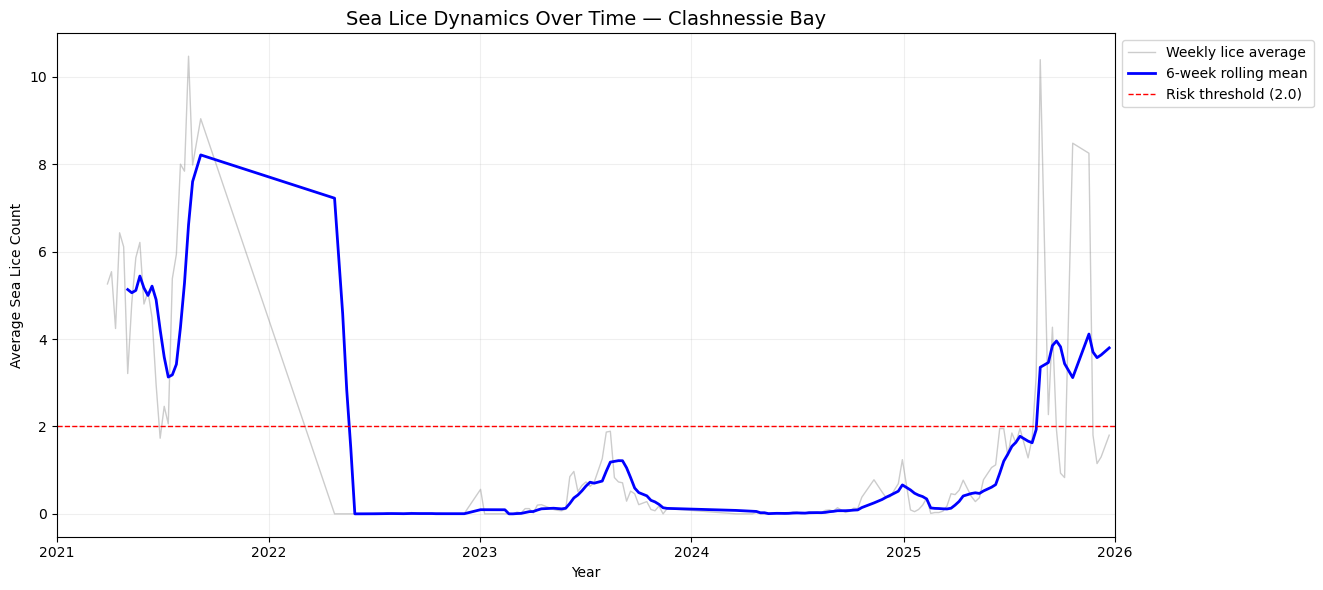

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Filter site
# ---------------------------
site_name = "Clashnessie Bay"

site_df = df[df["site_name"] == site_name].copy()

# Ensure correct order
site_df = site_df.sort_values("week_start")

# ---------------------------
# 2. Rolling average (trend line)
# ---------------------------
site_df["rolling_mean"] = site_df["lice_avg"].rolling(window=6).mean()

# ---------------------------
# 3. Plot setup
# ---------------------------
plt.figure(figsize=(14,6))

# Raw weekly data (noise / variability)
plt.plot(
    site_df["week_start"],
    site_df["lice_avg"],
    color="grey",
    alpha=0.4,
    linewidth=1,
    label="Weekly lice average"
)

# Smoothed trend (main signal)
plt.plot(
    site_df["week_start"],
    site_df["rolling_mean"],
    color="blue",
    linewidth=2,
    label="6-week rolling mean"
)

# ---------------------------
# 4. Risk threshold line
# (adjust if needed based on your earlier percentiles)
# ---------------------------
plt.axhline(
    y=2,
    color="red",
    linestyle="--",
    linewidth=1,
    label="Risk threshold (2.0)"
)

# ---------------------------
# 5. Formatting
# ---------------------------
plt.title(f"Sea Lice Dynamics Over Time — {site_name}", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Sea Lice Count")

plt.grid(alpha=0.2)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.tight_layout()
plt.subplots_adjust(right=0.8)
import matplotlib.dates as mdates

ax = plt.gca()

# Force full yearly range (key fix)
plt.xlim(pd.Timestamp("2021-01-01"), pd.Timestamp("2026-01-01"))

# Clean yearly ticks
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Save Figure

plt.savefig(
    "sealice_project/charts/clashnessie_bay_phase3_timeseries.pdf",
    bbox_inches="tight"
)
plt.show()